# Heart disease risk prediction: analysis

The notebook `Heart_Disease_Prediction.ipynb` in this folder fits a logistic regression on the Framingham dataset and reports only the training accuracy (86.0%).

This notebook builds on it with a more rigorous evaluation: a proper held-out test set, several models, ROC analysis, cross-validation and interpretation. The original file is kept alongside for comparison.

Target: `TenYearCHD`, whether the patient develops coronary heart disease within 10 years.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")  # silences a joblib core-count warning on Windows
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
SEED = 42
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, confusion_matrix, ConfusionMatrixDisplay)

df = pd.read_csv("framingham.csv")
print(df.shape)
df.head()

(4240, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 1. Data quality and class balance

Rows with at least one missing value: 582 of 4240


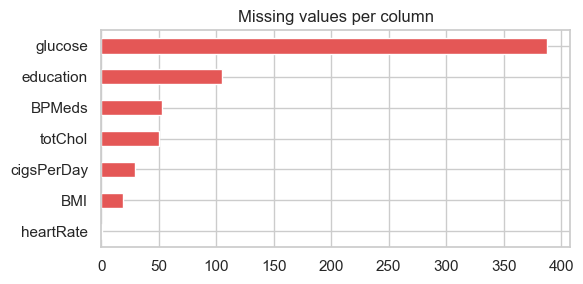

TenYearCHD
no CHD    0.848
CHD       0.152


In [2]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values()
print("Rows with at least one missing value:", int(df.isna().any(axis=1).sum()), "of", len(df))
missing.plot.barh(figsize=(6, 3), color="#E45756"); plt.title("Missing values per column"); plt.tight_layout(); plt.show()

balance = df["TenYearCHD"].value_counts(normalize=True).rename({0: "no CHD", 1: "CHD"})
print(balance.round(3).to_string())

Only about 15% of patients have the positive outcome, so a model that always predicts "no CHD" is already ~85% accurate. **Accuracy alone is therefore misleading here**, and the evaluation below uses ROC-AUC, recall and precision for the CHD class.

Preprocessing choices:
- `education` is dropped, as the original notebook intended.
- Missing values are filled with the median **inside the pipeline**, fitted on the training data only. The original plan was to drop all incomplete rows, which discards part of the data.
- Features are standardized so that logistic regression coefficients are comparable.

In [3]:
X = df.drop(columns=["TenYearCHD", "education"])
y = df["TenYearCHD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print("train:", X_train.shape, "| test:", X_test.shape, "| positive rate (train/test):",
      round(y_train.mean(), 3), round(y_test.mean(), 3))

train: (3392, 14) | test: (848, 14) | positive rate (train/test): 0.152 0.152


## 2. Models

In [4]:
prep = lambda: [SimpleImputer(strategy="median"), StandardScaler()]
models = {
    "Majority-class baseline": None,
    "Logistic Regression": make_pipeline(*prep(), LogisticRegression(max_iter=1000)),
    "Logistic Regression (balanced)": make_pipeline(*prep(), LogisticRegression(max_iter=1000, class_weight="balanced")),
    "Random Forest": make_pipeline(SimpleImputer(strategy="median"),
                                   RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=SEED)),
    "Gradient Boosting": HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=200, random_state=SEED),
}

rows, fitted, probas = [], {}, {}
for name, m in models.items():
    if m is None:
        pred = np.zeros(len(y_test), dtype=int); proba = np.zeros(len(y_test))
        auc = 0.5
    else:
        m.fit(X_train, y_train); fitted[name] = m
        pred = m.predict(X_test); proba = m.predict_proba(X_test)[:, 1]
        probas[name] = proba
        auc = roc_auc_score(y_test, proba)
    rows.append({"model": name, "accuracy": accuracy_score(y_test, pred),
                 "ROC-AUC": auc,
                 "precision (CHD)": precision_score(y_test, pred, zero_division=0),
                 "recall (CHD)": recall_score(y_test, pred, zero_division=0),
                 "F1 (CHD)": f1_score(y_test, pred, zero_division=0)})
results = pd.DataFrame(rows).set_index("model").round(3)
results

,accuracy,ROC-AUC,precision (CHD),recall (CHD),F1 (CHD)
model,,,,,
Majority-class baseline,0.848,0.500,0.000,0.000,0.000
Logistic Regression,0.844,0.702,0.412,0.054,0.096
Logistic Regression (balanced),0.671,0.700,0.255,0.605,0.359
Random Forest,0.846,0.664,0.375,0.023,0.044
Gradient Boosting,0.842,0.660,0.407,0.085,0.141


## 3. ROC curves and confusion matrix

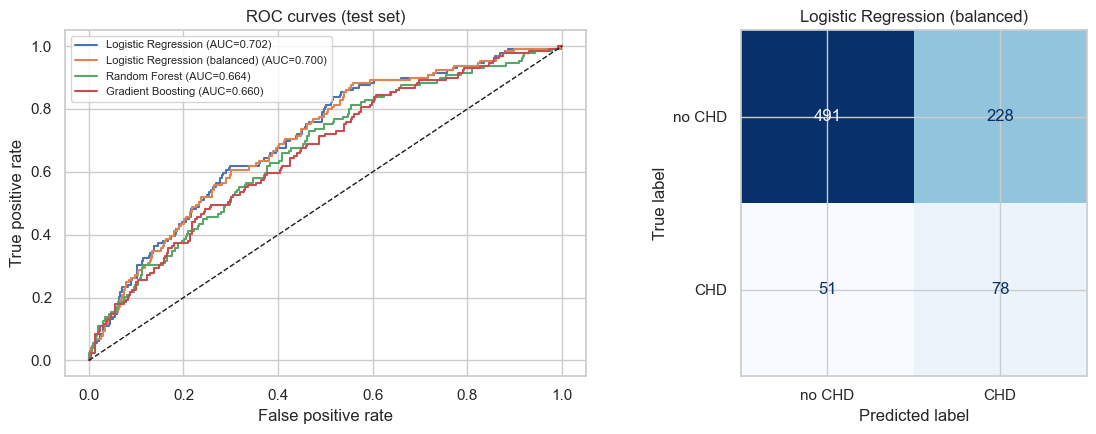

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, p in probas.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, p):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curves (test set)"); axes[0].legend(fontsize=8)

bal = fitted["Logistic Regression (balanced)"]
ConfusionMatrixDisplay(confusion_matrix(y_test, bal.predict(X_test)), display_labels=["no CHD", "CHD"]).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Logistic Regression (balanced)")
plt.tight_layout(); plt.show()

## 4. Cross-validated ROC-AUC

The test set has only ~120 positive cases, so the ranking above is noisy. Five-fold stratified CV on the full data:

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rows = []
for name, m in models.items():
    if m is None: continue
    s = cross_val_score(m, X, y, cv=cv, scoring="roc_auc")
    cv_rows.append({"model": name, "CV ROC-AUC": s.mean(), "± std": s.std()})
cv_results = pd.DataFrame(cv_rows).set_index("model").round(3)
cv_results

,CV ROC-AUC,± std
model,,
Logistic Regression,0.723,0.026
Logistic Regression (balanced),0.723,0.027
Random Forest,0.711,0.022
Gradient Boosting,0.699,0.018


## 5. Interpreting the logistic regression

Coefficients of the standardized features: positive values raise the predicted 10-year risk.

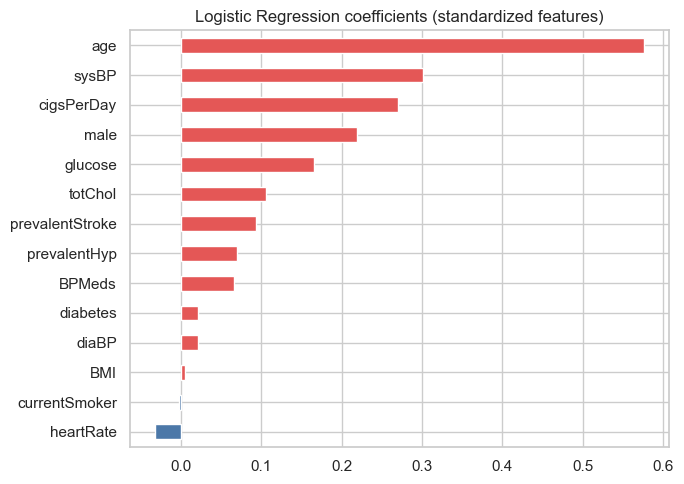

In [7]:
lr = fitted["Logistic Regression"]
coef = pd.Series(lr[-1].coef_[0], index=X.columns).sort_values()
colors = ["#E45756" if v > 0 else "#4C78A8" for v in coef]
coef.plot.barh(figsize=(7, 5), color=colors)
plt.title("Logistic Regression coefficients (standardized features)")
plt.tight_layout(); plt.show()

## Conclusions

- With only ~15% positive cases, every model has accuracy close to the **84.8% majority-class baseline**. Accuracy cannot be used to compare them.
- Ranking by cross-validated ROC-AUC, plain **Logistic Regression is best (0.723)**; Random Forest (0.711) and Gradient Boosting (0.699) do not improve on it. A simple, interpretable model is the right choice for this dataset.
- At the default 0.5 threshold, Logistic Regression finds only **5% of the patients who develop CHD** (precision 41%). Re-weighting the classes raises recall to **60.5%**, at the cost of precision falling to 25.5% and accuracy to 67%. Which trade-off is right depends on the cost of a missed patient versus a false alarm, and should be set deliberately, not left at the default.
- The largest coefficients are **age, systolic blood pressure, cigarettes per day, sex (male) and glucose**, in line with well-known cardiovascular risk factors.

**Caveats:** moderate predictive power overall (AUC ≈ 0.72); 582 rows had missing values and were median-imputed; no calibration analysis was done; this is not medical advice.